# Goal: inspect correlations between parameters

We basically have 
P, e, M1, M2, and M2/M1

We already have
- P(e) 
- M1(M2)

not useful
- M1(M2/M1)

In this notebook we'll do
- P(M1/M2)
- e (M2/M1) 

- P(M1)
- P(M2)
- e (M1)
- e (M2)


(LvS: 30-03-26)

In [1]:
import json
import numpy as np
import pandas as pd
import sys, os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import gaussian_kde

from pathlib import Path

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import DUMMY_CATALOG, MAIN_CATALOG, PLOTS_DIR, DOCS_DIR, LATEX_PLOT_DIR

file_path = MAIN_CATALOG


# Use mathtext (LaTeX-like without needing LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern math font
plt.rcParams['font.size'] = 12


### Read json catalog into pandas table

In [2]:
# === Load JSON ===
def read_json_file(file_path):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

def extract_triplet_array(data, key):
    """Return an (N,3) float array for the given triplet key, robust to None/NaN."""
    rows = []
    for entry in data:
        val = entry.get(key, None)
        if isinstance(val, (list, tuple, np.ndarray)) and len(val) == 3:
            try:
                # Convert None to np.nan before float conversion
                rows.append([
                    np.nan if val[0] is None else float(val[0]),
                    np.nan if val[1] is None else float(val[1]),
                    np.nan if val[2] is None else float(val[2])
                ])
            except (TypeError, ValueError):
                rows.append([np.nan, np.nan, np.nan])
        elif isinstance(val, (int, float)):
            # Scalar provided, treat as central value with unknown errors
            rows.append([np.nan, float(val), np.nan])
        else:
            rows.append([np.nan, np.nan, np.nan])
    return np.array(rows, dtype=float)

In [3]:
# Read data
data = read_json_file(str(MAIN_CATALOG))
if data is None:
    print("No data loaded. Exiting.")
    exit(1)


In [4]:
# Extract triplet columns once for efficiency/consistency
RA_arr = extract_triplet_array(data, 'RA')
Dec_arr = extract_triplet_array(data, 'Dec')
period_arr = extract_triplet_array(data, 'Period')
ecc_arr = extract_triplet_array(data, 'Eccentricity')
m1_arr = extract_triplet_array(data, 'M1')
m2_arr = extract_triplet_array(data, 'M2')

# Build a single DataFrame with central values and errors
catalog_df = pd.DataFrame({
    'System Name': [entry.get('System Name', '') for entry in data],
    'RA': RA_arr[:, 1],
    'Dec': Dec_arr[:, 1],
    'Period': period_arr[:, 1],
    'Period_err_minus': period_arr[:, 0],
    'Period_err_plus': period_arr[:, 2],
    'Eccentricity': ecc_arr[:, 1],
    'Eccentricity_err_minus': ecc_arr[:, 0],
    'Eccentricity_err_plus': ecc_arr[:, 2],
    'M1': m1_arr[:, 1],
    'M1_err_minus': m1_arr[:, 0],
    'M1_err_plus': m1_arr[:, 2],
    'M2': m2_arr[:, 1],
    'M2_err_minus': m2_arr[:, 0],
    'M2_err_plus': m2_arr[:, 2],
    'obs_type_1': [entry.get('obs_type_1', '') for entry in data],
    'obs_type_2': [entry.get('obs_type_2', '') for entry in data],
    'evol_type_1': [entry.get('evol_type_1', '') for entry in data],
    'evol_type_2': [entry.get('evol_type_2', '') for entry in data],
    'system_class': [entry.get('system_class', 'None') for entry in data],
    'Simbad': [entry.get('Simbad', None) for entry in data]
})

In [5]:
display(catalog_df)

,System Name,RA,Dec,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,...,M1_err_plus,M2,M2_err_minus,M2_err_plus,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
0,Cl* NGC 188 PKM 451,8.700020,85.540940,722.000000,4.000000e+00,4.000000e+00,0.34,0.03,0.03,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
1,Cl* NGC 188 PKM 1888,13.631330,85.535900,2240.000000,3.000000e+01,3.000000e+01,0.21,0.04,0.04,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
2,Cl* NGC 188 PKM 2679,6.685930,85.310000,1033.000000,8.000000e+00,8.000000e+00,0.07,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
3,Cl* NGC 188 PKM 4348,10.923210,85.221480,1168.000000,8.000000e+00,8.000000e+00,0.09,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4,Cl* NGC 188 PKM 4540,11.326540,85.322200,3030.000000,7.000000e+01,7.000000e+01,0.36,0.07,0.07,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4704,UCAC4 495-142916,297.473341,8.904363,0.748668,1.600000e-06,1.600000e-06,NaN,NaN,NaN,1.69,...,0.07,0.31,0.07,0.07,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4705,CRTS J225539.4+342138,118.713529,34.360512,0.571785,3.000000e-07,3.000000e-07,NaN,NaN,NaN,1.40,...,0.04,0.26,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4706,UCAC4 646-116578,123.282814,39.139678,0.766129,3.800000e-06,3.800000e-06,NaN,NaN,NaN,1.60,...,0.08,0.16,0.05,0.05,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4707,ZTF J225755.64+310133.7,127.228463,31.026046,0.688416,4.000000e-07,4.000000e-07,NaN,NaN,NaN,1.65,...,0.06,0.29,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


In [6]:
# System-class colours and symbols — imported from the shared module.
# Edit code/data_analysis/Category_dict.py to change colours/symbols everywhere.
import importlib

from Category_dict import SYSTEM_CLASS_MAP, STYLE_MAP, COLORMAP, SYMBOLMAP
importlib.reload(sys.modules['Category_dict'])  # Ensure we have the latest version of the dict after edits

<module 'Category_dict' from '/Users/liekevanson/Documents/Projects/post_mt_review/code/data_analysis/Category_dict.py'>

# Eccentricity (M2/M1)

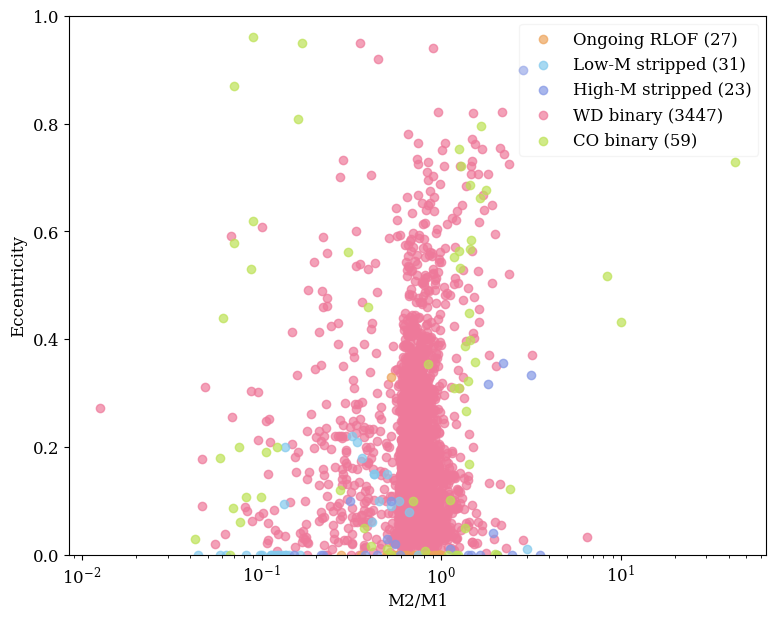

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = catalog_df.copy()


# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    zorder = 1
    if category == 'WD binary':
        zorder = 0
    # Combine all system classes in this category
    system_classes_in_category = list(systems.keys())
    subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)]
    
    first_system_color = list(systems.values())[0]['color']

    ###### Actual plotting ######
    x = subset['M2']/subset['M1']
    y = subset['Eccentricity'] #np.log10(subset['Period'])
    both_not_na = np.logical_and(x.notna(), y.notna())
    # print('sum(both_not_na)', sum(both_not_na), 'len(x)', len(x))
    ax.scatter(x[both_not_na], y[both_not_na],  #past donor over accretor
                c=first_system_color, alpha=0.7,zorder = zorder,
                label=f"{category} ({sum(both_not_na)})")  

# plt.hlines(1, xmin = -3, xmax = 5, ls = '--', color='k')

# Write x ticks not in log space but in days
# xticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
# xtick_labels = ['0.01', '0.1', '1', '10', '100', '1000', '$10^4$']
# plt.xticks(np.log10(xticks), xtick_labels, fontsize=20) 


plt.ylabel('Eccentricity')
# plt.xlabel('log Period')
plt.xlabel('M2/M1')
plt.xscale('log')
plt.ylim(0,1)
# plt.xlim(-2.5, 4.5)
plt.legend(framealpha = 0.2)#, loc = 'lower left')
plt.savefig(PLOTS_DIR / 'M2_over_M1_vs_eccentricity_by_category.pdf')
plt.show()



# M2/M1(P)

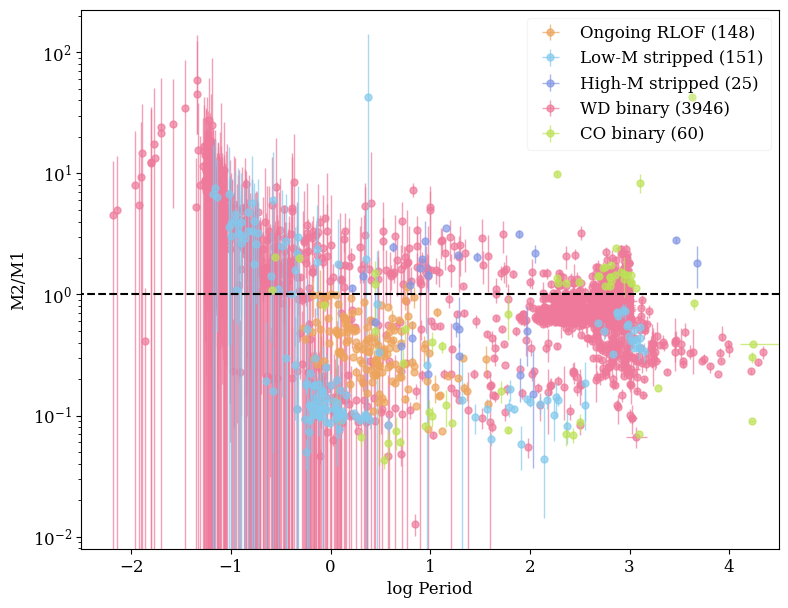

In [28]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = catalog_df.copy()

# Keep only rows where ratios/logs are physical.
plot_df = plot_df[(plot_df['Period'] > 0) & (plot_df['M1'] > 0) & (plot_df['M2'] > 0)].copy()

# x errors in log10(Period): d(log10 P) = dP / (P ln 10)
plot_df['period_err_minus'] = plot_df['Period_err_minus'].fillna(0)
plot_df['period_err_plus'] = plot_df['Period_err_plus'].fillna(0)
plot_df['period_err_minus_log'] = plot_df['period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['period_err_plus'] / (plot_df['Period'] * np.log(10))

# y = q = M2/M1 with propagated asymmetric errors
plot_df['M1_err_minus'] = plot_df['M1_err_minus'].fillna(0)
plot_df['M1_err_plus'] = plot_df['M1_err_plus'].fillna(0)
plot_df['M2_err_minus'] = plot_df['M2_err_minus'].fillna(0)
plot_df['M2_err_plus'] = plot_df['M2_err_plus'].fillna(0)

plot_df['q'] = plot_df['M2'] / plot_df['M1']
plot_df['q_err_minus'] = plot_df['q'] * np.sqrt(
    (plot_df['M2_err_minus'] / plot_df['M2'])**2 +
    (plot_df['M1_err_minus'] / plot_df['M1'])**2
)
plot_df['q_err_plus'] = plot_df['q'] * np.sqrt(
    (plot_df['M2_err_plus'] / plot_df['M2'])**2 +
    (plot_df['M1_err_plus'] / plot_df['M1'])**2
)

# Keep q error bars physical for log-y plotting.
plot_df.loc[plot_df['q_err_minus'] > plot_df['q'], 'q_err_minus'] = plot_df['q']

# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    zorder = 1
    if category == 'WD binary':
        zorder = 0
    
    # Combine all system classes in this category
    system_classes_in_category = list(systems.keys())
    subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)].copy()

    first_system_color = list(systems.values())[0]['color']

    ###### Actual plotting ######
    x = np.log10(subset['Period'])
    y = subset['q']
    both_not_na = np.logical_and(x.notna(), y.notna())

    ax.errorbar(
        x[both_not_na], y[both_not_na],
        xerr=[subset.loc[both_not_na, 'period_err_minus_log'], subset.loc[both_not_na, 'period_err_plus_log']],
        yerr=[subset.loc[both_not_na, 'q_err_minus'], subset.loc[both_not_na, 'q_err_plus']],
        fmt='o', ms=5, c=first_system_color, ecolor=first_system_color,
        elinewidth=1, capsize=0, alpha=0.7, zorder=zorder,
        label=f"{category} ({sum(both_not_na)})"
    )

plt.hlines(1, xmin=-3, xmax=5, ls='--', color='k')

plt.xlabel('log Period')
plt.ylabel('M2/M1')
plt.yscale('log')
plt.xlim(-2.5, 4.5)
plt.legend(framealpha=0.2)
plt.show()


# Eccentricity(M1)

/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


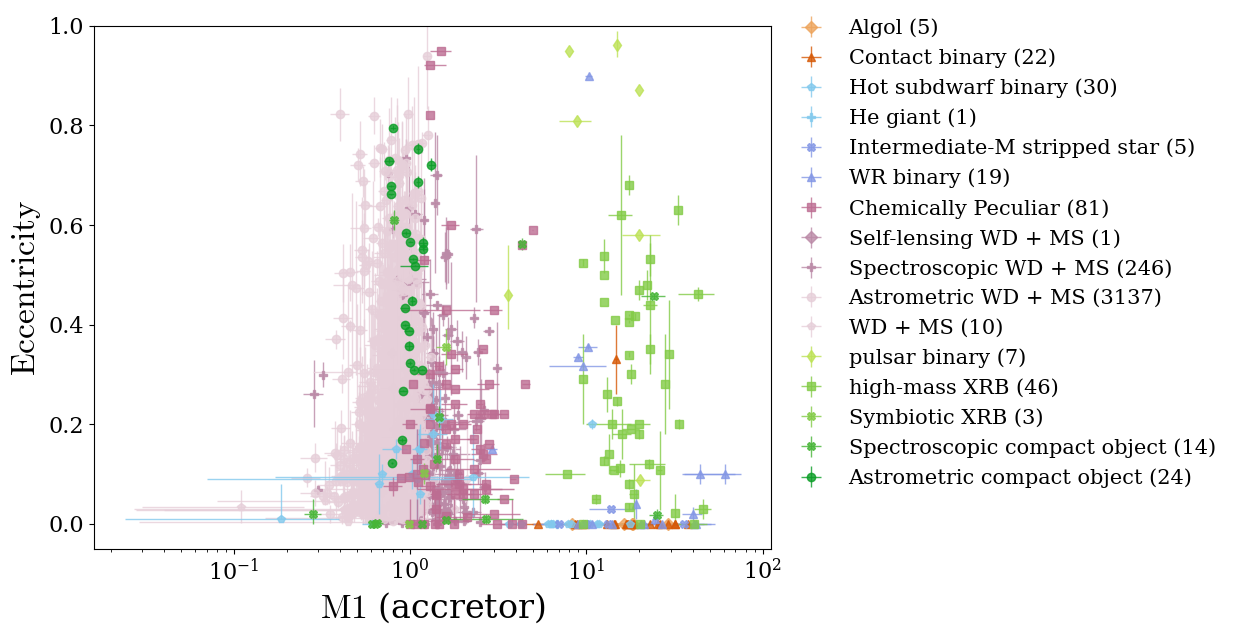

In [16]:
fig, ax = plt.subplots(figsize=(12.5, 6.5))

plot_df = catalog_df.copy()

# Keep only rows with valid central values; log-x also requires Period > 0.
plot_df = plot_df.dropna(subset=['Eccentricity', 'M1']).copy()

# Keep eccentricity errors physical: e - err >= 0 and e + err <= 1
mask_min = plot_df['Eccentricity'] - plot_df['Eccentricity_err_minus'] < 0
plot_df.loc[mask_min, 'Eccentricity_err_minus'] = plot_df.loc[mask_min, 'Eccentricity']
mask_plus = plot_df['Eccentricity'] + plot_df['Eccentricity_err_plus'] > 1
plot_df.loc[mask_plus, 'Eccentricity_err_plus'] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Missing uncertainties are treated as zero-length error bars
plot_df['M1_err_minus'] = plot_df['M1_err_minus'].fillna(0)
plot_df['M1_err_plus'] = plot_df['M1_err_plus'].fillna(0)
plot_df['Eccentricity_err_minus'] = plot_df['Eccentricity_err_minus'].fillna(0)
plot_df['Eccentricity_err_plus'] = plot_df['Eccentricity_err_plus'].fillna(0)

# Keep error bars physical: no negative period, and eccentricity bounded [0,1].
mask_emin = plot_df['Eccentricity'] - plot_df['Eccentricity_err_minus'] < 0
plot_df.loc[mask_emin, 'Eccentricity_err_minus'] = plot_df.loc[mask_emin, 'Eccentricity']

mask_eplus = plot_df['Eccentricity'] + plot_df['Eccentricity_err_plus'] > 1
plot_df.loc[mask_eplus, 'Eccentricity_err_plus'] = 1 - plot_df.loc[mask_eplus, 'Eccentricity']

# Plotly-style symbols mapped to matplotlib markers.
plotly_to_mpl_marker = {
    'circle': 'o',
    'circle-open': 'o',
    'square': 's',
    'square-open': 's',
    'diamond': 'D',
    'diamond-open': 'D',
    'diamond-tall': 'd',
    'cross': 'P',
    'cross-dot': 'P',
    'x': 'X',
    'triangle-up': '^',
    'triangle-up-open': '^',
    'star': '*',
    'pentagon': 'p',
    'pentagon-open': 'p',
    'hourglass': 'H',
}


# Plot each system class separately so style/legend are per class.
for system_class in STYLE_MAP.keys():
    sub = plot_df[plot_df['system_class'] == system_class]
    if sub.empty:
        continue
    # Move the WDs to the back
    Zord = 3 if 'WD' not in system_class else 0

    color = COLORMAP.get(system_class, '#666666')
    marker_plotly = SYMBOLMAP.get(system_class, 'circle')
    marker_mpl = plotly_to_mpl_marker.get(marker_plotly, 'o')

    ax.errorbar(sub['M1'],sub['Eccentricity'],
        xerr=[sub['M1_err_minus'], sub['M1_err_plus']],
        yerr=[sub['Eccentricity_err_minus'], sub['Eccentricity_err_plus']],
        fmt=marker_mpl,ms=6,color=color,ecolor=color,
        elinewidth=1,capsize=0,alpha=0.8,
        linestyle='none', zorder = Zord, 
        label=f"{system_class} ({len(sub)})"
    )


ax.set_xscale('log')    
ax.set_ylim(-0.05, 1)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('$\mathrm{M1}$ (accretor)', fontsize=24)
ax.set_ylabel('$\mathrm{Eccentricity}$', fontsize=24)
ax.legend(bbox_to_anchor=(1, 1.05), loc='upper left', fontsize=15, framealpha=0., ncol=1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'P_M1_by_system_class.pdf')
plt.show()

Notes: there is somewhat of a bimodality in the accretor massrs: they are either low-mass (below ~3Msun), or high mass (above 10Msun)
In between these two populations there are only a few systems, and they have basically zero eccentricity.

/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


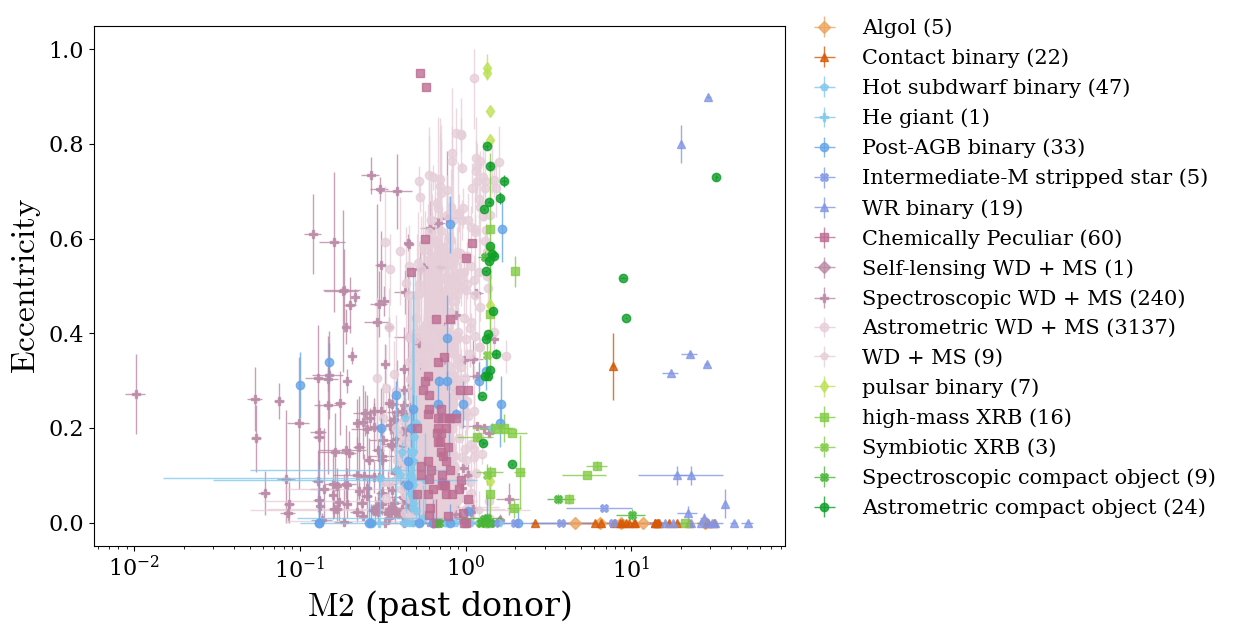

In [15]:
fig, ax = plt.subplots(figsize=(12.5, 6.5))

plot_df = catalog_df.copy()

# Keep only rows with valid central values; log-x also requires Period > 0.
plot_df = plot_df.dropna(subset=['Eccentricity', 'M2']).copy()

# Keep eccentricity errors physical: e - err >= 0 and e + err <= 1
mask_min = plot_df['Eccentricity'] - plot_df['Eccentricity_err_minus'] < 0
plot_df.loc[mask_min, 'Eccentricity_err_minus'] = plot_df.loc[mask_min, 'Eccentricity']
mask_plus = plot_df['Eccentricity'] + plot_df['Eccentricity_err_plus'] > 1
plot_df.loc[mask_plus, 'Eccentricity_err_plus'] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Missing uncertainties are treated as zero-length error bars
plot_df['M2_err_minus'] = plot_df['M2_err_minus'].fillna(0)
plot_df['M2_err_plus'] = plot_df['M2_err_plus'].fillna(0)
plot_df['Eccentricity_err_minus'] = plot_df['Eccentricity_err_minus'].fillna(0)
plot_df['Eccentricity_err_plus'] = plot_df['Eccentricity_err_plus'].fillna(0)

# Keep error bars physical: no negative period, and eccentricity bounded [0,1].
mask_emin = plot_df['Eccentricity'] - plot_df['Eccentricity_err_minus'] < 0
plot_df.loc[mask_emin, 'Eccentricity_err_minus'] = plot_df.loc[mask_emin, 'Eccentricity']

mask_eplus = plot_df['Eccentricity'] + plot_df['Eccentricity_err_plus'] > 1
plot_df.loc[mask_eplus, 'Eccentricity_err_plus'] = 1 - plot_df.loc[mask_eplus, 'Eccentricity']

# Plotly-style symbols mapped to matplotlib markers.
plotly_to_mpl_marker = {
    'circle': 'o',
    'circle-open': 'o',
    'square': 's',
    'square-open': 's',
    'diamond': 'D',
    'diamond-open': 'D',
    'diamond-tall': 'd',
    'cross': 'P',
    'cross-dot': 'P',
    'x': 'X',
    'triangle-up': '^',
    'triangle-up-open': '^',
    'star': '*',
    'pentagon': 'p',
    'pentagon-open': 'p',
    'hourglass': 'H',
}


# Plot each system class separately so style/legend are per class.
for system_class in STYLE_MAP.keys():
    sub = plot_df[plot_df['system_class'] == system_class]
    if sub.empty:
        continue
    # Move the WDs to the back
    Zord = 3 if 'WD' not in system_class else 0

    color = COLORMAP.get(system_class, '#666666')
    marker_plotly = SYMBOLMAP.get(system_class, 'circle')
    marker_mpl = plotly_to_mpl_marker.get(marker_plotly, 'o')

    ax.errorbar(sub['M2'],sub['Eccentricity'],
        xerr=[sub['M2_err_minus'], sub['M2_err_plus']],
        yerr=[sub['Eccentricity_err_minus'], sub['Eccentricity_err_plus']],
        fmt=marker_mpl,ms=6,color=color,ecolor=color,
        elinewidth=1,capsize=0,alpha=0.8,
        linestyle='none', zorder = Zord, 
        label=f"{system_class} ({len(sub)})"
    )


ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('$\mathrm{M2}$ (past donor)', fontsize=24)
ax.set_ylabel('$\mathrm{Eccentricity}$', fontsize=24)
ax.legend(bbox_to_anchor=(1, 1.05), loc='upper left', fontsize=15, framealpha=0., ncol=1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'P_M2_by_system_class.pdf')
plt.show()

Note: the (presumed) donore are mostly quite low mass (below 3Msun). There are only few systems with higher masses and still significant eccentricity. Most higher mass donors are 'ongoing RLOF' and 'high-mass stripped stars', and these are more concentrated around zero eccentricity. 

# M1(P)

/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


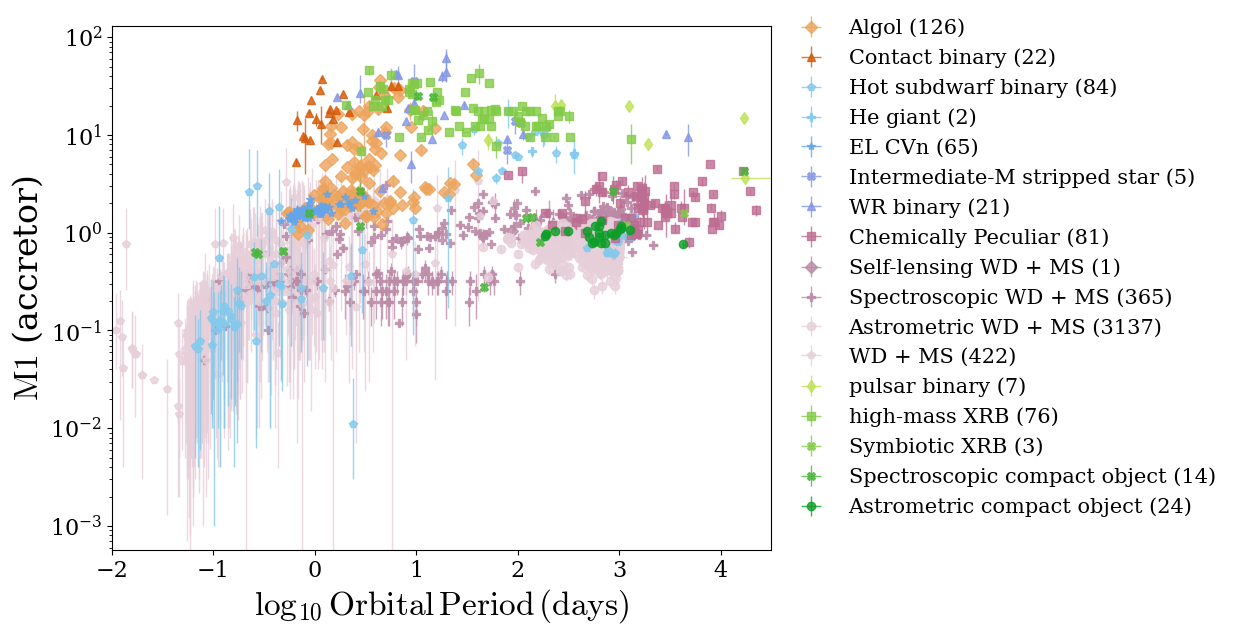

In [22]:
fig, ax = plt.subplots(figsize=(12.5, 6.5))

plot_df = catalog_df.copy()

# Keep only rows with valid central values; log-x also requires Period > 0.
plot_df = plot_df.dropna(subset=['Period', 'M1']).copy()
plot_df = plot_df[plot_df['Period'] > 0].copy()

# Propagate Period errors into log10 space: d(log P) = dP / (P ln 10)
plot_df['period_err_minus_log'] = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Missing uncertainties are treated as zero-length error bars
plot_df['period_err_minus_log'] = plot_df['period_err_minus_log'].fillna(0)
plot_df['period_err_plus_log'] = plot_df['period_err_plus_log'].fillna(0)
plot_df['M1_err_minus'] = plot_df['M1_err_minus'].fillna(0)
plot_df['M1_err_plus'] = plot_df['M1_err_plus'].fillna(0)

# Keep error bars physical: no negative period,
mask_pmin = plot_df['Period'] - plot_df['Period_err_minus'] < 0
plot_df.loc[mask_pmin, 'Period_err_minus'] = plot_df.loc[mask_pmin, 'Period']

# Plotly-style symbols mapped to matplotlib markers.
plotly_to_mpl_marker = {
    'circle': 'o',
    'circle-open': 'o',
    'square': 's',
    'square-open': 's',
    'diamond': 'D',
    'diamond-open': 'D',
    'diamond-tall': 'd',
    'cross': 'P',
    'cross-dot': 'P',
    'x': 'X',
    'triangle-up': '^',
    'triangle-up-open': '^',
    'star': '*',
    'pentagon': 'p',
    'pentagon-open': 'p',
    'hourglass': 'H',
}


# Plot each system class separately so style/legend are per class.
for system_class in STYLE_MAP.keys():
    sub = plot_df[plot_df['system_class'] == system_class]
    if sub.empty:
        continue
    # Move the WDs to the back
    Zord = 3 if 'WD' not in system_class else 0

    color = COLORMAP.get(system_class, '#666666')
    marker_plotly = SYMBOLMAP.get(system_class, 'circle')
    marker_mpl = plotly_to_mpl_marker.get(marker_plotly, 'o')

    ax.errorbar(np.log10(sub['Period']),sub['M1'],
        xerr=[sub['period_err_minus_log'], sub['period_err_plus_log']],
        yerr=[sub['M1_err_minus'], sub['M1_err_plus']],
        fmt=marker_mpl,ms=6,color=color,ecolor=color,
        elinewidth=1,capsize=0,alpha=0.8,
        linestyle='none', zorder = Zord, 
        label=f"{system_class} ({len(sub)})"
    )


ax.set_xlim(-2, 4.5)
ax.set_yscale('log')
# ax.set_ylim(-0.05, 1)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('$\mathrm{\log_{10} Orbital\,Period\,(days)}$', fontsize=24)
ax.set_ylabel('$\mathrm{M1}$ (accretor)', fontsize=24)
ax.legend(bbox_to_anchor=(1, 1.05), loc='upper left', fontsize=15, framealpha=0., ncol=1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'P_M1_by_system_class.pdf')
plt.show()

The WDs and hot subdwarfs follow a similar relation at short periods: larger period is higher accretor mass?
A lot of the accretor masses are quite constant with P, though there is a lot of spread in accretor masses. 

# M2(P)

/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


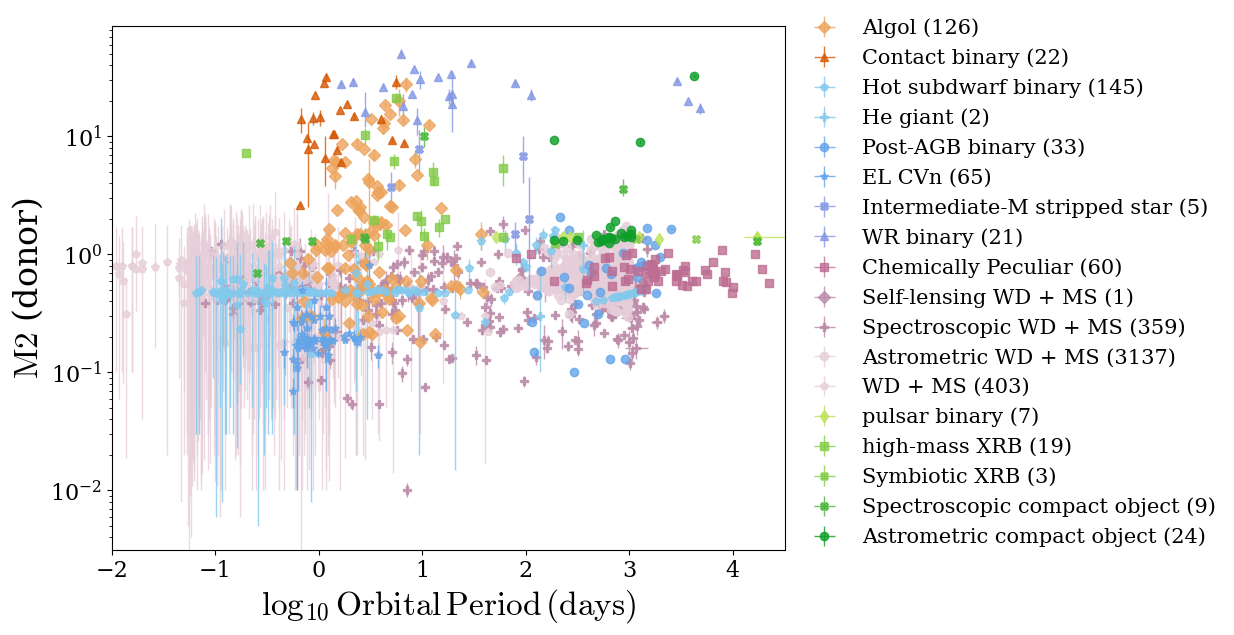

In [25]:
fig, ax = plt.subplots(figsize=(12.5, 6.5))

plot_df = catalog_df.copy()

# Keep only rows with valid central values; log-x also requires Period > 0.
plot_df = plot_df.dropna(subset=['Period', 'M2']).copy()
plot_df = plot_df[plot_df['Period'] > 0].copy()

# Propagate Period errors into log10 space: d(log P) = dP / (P ln 10)
plot_df['period_err_minus_log'] = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Missing uncertainties are treated as zero-length error bars
plot_df['period_err_minus_log'] = plot_df['period_err_minus_log'].fillna(0)
plot_df['period_err_plus_log'] = plot_df['period_err_plus_log'].fillna(0)
plot_df['M2_err_minus'] = plot_df['M2_err_minus'].fillna(0)
plot_df['M2_err_plus'] = plot_df['M2_err_plus'].fillna(0)

# Keep error bars physical: no negative period,
mask_pmin = plot_df['Period'] - plot_df['Period_err_minus'] < 0
plot_df.loc[mask_pmin, 'Period_err_minus'] = plot_df.loc[mask_pmin, 'Period']

# Plotly-style symbols mapped to matplotlib markers.
plotly_to_mpl_marker = {
    'circle': 'o',
    'circle-open': 'o',
    'square': 's',
    'square-open': 's',
    'diamond': 'D',
    'diamond-open': 'D',
    'diamond-tall': 'd',
    'cross': 'P',
    'cross-dot': 'P',
    'x': 'X',
    'triangle-up': '^',
    'triangle-up-open': '^',
    'star': '*',
    'pentagon': 'p',
    'pentagon-open': 'p',
    'hourglass': 'H',
}


# Plot each system class separately so style/legend are per class.
for system_class in STYLE_MAP.keys():
    sub = plot_df[plot_df['system_class'] == system_class]
    if sub.empty:
        continue
    # Move the WDs to the back
    Zord = 3 if 'WD' not in system_class else 0

    color = COLORMAP.get(system_class, '#666666')
    marker_plotly = SYMBOLMAP.get(system_class, 'circle')
    marker_mpl = plotly_to_mpl_marker.get(marker_plotly, 'o')

    ax.errorbar(np.log10(sub['Period']),sub['M2'],
        xerr=[sub['period_err_minus_log'], sub['period_err_plus_log']],
        yerr=[sub['M2_err_minus'], sub['M2_err_plus']],
        fmt=marker_mpl,ms=6,color=color,ecolor=color,
        elinewidth=1,capsize=0,alpha=0.8,
        linestyle='none', zorder = Zord, 
        label=f"{system_class} ({len(sub)})"
    )


ax.set_xlim(-2, 4.5)
ax.set_yscale('log')
# ax.set_ylim(-0.05, 1)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('$\mathrm{\log_{10} Orbital\,Period\,(days)}$', fontsize=24)
ax.set_ylabel('$\mathrm{M2}$ (donor)', fontsize=24)
ax.legend(bbox_to_anchor=(1, 1.05), loc='upper left', fontsize=15, framealpha=0., ncol=1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'P_M2_by_system_class.pdf')
plt.show()

Donor masses per category are quite constant over period, with the exception of Algols that seem to span a larger range of masses. 
There does not seem to be a clear gap in the distribution, but if anything, it might thin a bit around 10d